# EmporiUm Sales Territory Analysis
**Analyst:** Sharleen Guerrero  
**Territories:** Texas (South Region) & New Jersey (Northeast Region) — *Cross-Region Comparison*  
**Territory Managers:** Jeff "Howdy" Richards (TX) | Miami Vue (NJ)  
**Project Objective:** The objective of this project is to conduct a comprehensive 
business analysis of five datasets covering store details and product performance 
across regions for a fictional bookstore chain called EmporiUm. The analysis focuses 
on comparing the South and Northeast regions, specifically the Texas and New Jersey 
sales territories. Key insights will be explored using Python libraries NumPy, Pandas, 
and Matplotlib to identify performance trends, and data-driven recommendations will 
be provided for where to focus marketing attention in the next quarter. All analysis and findings are documented in this Jupyter Notebook. Visualizations and dashboard are located in [Guerrero_Dashboard.ipynb](Guerrero_Dashboard.ipynb).

---

## 1. Loading and Inspecting Data with Pandas

In [28]:
# ====== Importing necessary libraries ======

# pandas — data manipulation and DataFrames 
import pandas as pd

# numpy — numerical computing, used for array operations 
import numpy as np

# matplotlib — creating stati|c charts and visualizations 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # formatting axis tick labels (ex. currency symbols)

In [2]:
# ====== Creating DataFrames ======

# pd.read_csv() - A Pandas library function that converts csv files into DataFrames
# df.info() Gives column names, data types, and non-null values
# df.head() shows first 5 rows 
# df.shape returns a tuple with DataFrame dimensions (rows, columns)

# ------ customer_list.csv --------# 

# raw customer_list.csv uses pipe symbols | as delimiters
# split by '|' to properly display columns
customer_list = pd.read_csv("customer_list.csv", sep='|')

# DataFrame Inspection Methods & Attributes
print("\n----------- customer_list info: ----------\n")
customer_list.info()
print("\ncustomer_list Shape:", customer_list.shape)
print("\n------------ Initial Rows: ----------------\n")
customer_list.head()


----------- customer_list info: ----------

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB

customer_list Shape: (521, 7)

------------ Initial Rows: ----------------



,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [3]:
# ------ ProductCategories.csv --------# 

product_categories = pd.read_csv("ProductCategories.csv")

print("\n----------- product_categories info: ----------\n")
product_categories.info()
print("\nproduct_categories Shape:", product_categories.shape)
print("\n--------------- Initial Rows: ------------------\n")
product_categories.head()


----------- product_categories info: ----------

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB

product_categories Shape: (52, 4)

--------------- Initial Rows: ------------------



,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [4]:
# ------ Products.csv --------# 
products = pd.read_csv("Products.csv")

print("\n------------ products info: ------------\n")
products.info()
print("\nproducts Shape:", products.shape)
print("\n-------------Initial Rows: -------------\n")
products.head()


------------ products info: ------------

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB

products Shape: (669, 4)

-------------Initial Rows: -------------



,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
# ------ StoreDetails.csv --------# 
store_details = pd.read_csv("StoreDetail.csv")

print("\n----------- store_details info: ----------\n")
store_details.info()
print("\nstore_details Shape:", store_details.shape)
print("\n------------ Initial Rows: ----------------\n")
store_details.head()


----------- store_details info: ----------

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB

store_details Shape: (111, 6)

------------ Initial Rows: ----------------



,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [6]:
# ------ StoreSales.csv --------# 
store_sales = pd.read_csv("StoreSales.csv")

print("\n----------- store_sales info: ----------\n")
store_sales.info()
print("\nstore_sales Shape:", store_sales.shape)
print("\n------------ Initial Rows: ----------------\n")
store_sales.head()


----------- store_sales info: ----------

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB

store_sales Shape: (335129, 5)

------------ Initial Rows: ----------------



,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


### 1.A Initial Data Inspection Observations

- Transaction Date in StoreSales (and possibly customer_list) must be converted to datetime using pd.to_datetime() before analysis to perform date operations
- RewardsID is float because NaN values exist, indicating non-rewards customers. Pandas automatically converts int columns with NaN to float
- Prod Num and SubcategoryID are intentionally strings because they include letters. Primary use is labels and join keys, not calculation.
- Null values were found in RewardsID (300,186 nulls) indicating 
  non-rewards customers, and minor nulls in customer_list phone 
  and sms-opt-out columns (1 null each). This doesn't impede overall analysis.

### 1.B Data Cleaning

In [7]:
# Priority is converting Transaction Date column in store_sales from a default string to 
# date for chronological awareness using pd.to_datetime method
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Creating a YearMonth column for seamless grouping by transaction months for analysis
store_sales['YearMonth'] = store_sales['Transaction Date'].dt.to_period('M')

# Verifying Both Changes
store_sales[['Transaction Date', 'YearMonth']].head()

,Transaction Date,YearMonth
0,2022-01-01,2022-01
1,2022-01-01,2022-01
2,2022-01-01,2022-01
3,2022-01-01,2022-01
4,2022-01-01,2022-01


In [8]:
# What is the full date range of the data?
print(store_sales['YearMonth'].min())
print(store_sales['YearMonth'].max())

2022-01
2025-12


**Data covers 48 months of transactions from January 2022 through December 2025.**

---

## 2. Core Marketing Analysis

This analysis examines sales performance across the Texas and New Jersey territories, covering revenue trends, store rankings, customer behavior, product category performance, and marketing recommendations for the next quarter.


### Q1 | Territory Overview
*Who are the territory managers for the sales territories assigned?*

In [9]:
# Using .isin() function to filter information by assigned territories and store the result 
# in a assigned territory table for automatically filtered analysis
assigned_territories = store_details[store_details['State'].isin(['Texas', 'New Jersey'])]

# Finding territory manager names for each assigned state and storing them in respective variables
# .unique() returns an array of distinct values; [0] extracts the first item as a string
texas_manager = assigned_territories[assigned_territories['State'] == 'Texas']['Territory Manager'].unique()[0]
nj_manager = assigned_territories[assigned_territories['State'] == 'New Jersey']['Territory Manager'].unique()[0]

# Printing the results
print(f"Territory Manager for Texas: {texas_manager}")
print(f"Territory Manager for New Jersey: {nj_manager}")

Territory Manager for Texas: Jeff "Howdy" Richards
Territory Manager for New Jersey: Miami Vue


&nbsp;

*What are the store IDs and cities for the stores in each assigned sales territory?*

In [10]:
# Filtering only relevant columns for Texas territory stores

texas_stores = assigned_territories[assigned_territories['State'] == 'Texas'][['Store Location', 'Store ID', 'Region']]
print(f"\nTexas has {len(texas_stores)} stores")
texas_stores


Texas has 11 stores


,Store Location,Store ID,Region
100,Arlington,901,South
101,Austin,902,South
102,Bacliff,903,South
103,Baytown,904,South
104,Beaumont,905,South
105,Cedar Park,906,South
106,Dallas,907,South
107,Denton,908,South
108,Desoto,909,South
109,Fort Worth,910,South


In [11]:
# Filtering only relevant columns for New Jersey territory stores

nj_stores = assigned_territories[assigned_territories['State'] == 'New Jersey'][['Store Location', 'Store ID', 'Region']]
print(f"\nNew Jersey has {len(nj_stores)} stores")
nj_stores


New Jersey has 16 stores


,Store Location,Store ID,Region
70,Atlantic City,824,Northeast
71,Bayonne,825,Northeast
72,Cape May,826,Northeast
73,Clifton,827,Northeast
74,East Orange,828,Northeast
75,Hackensack,829,Northeast
76,Hoboken,830,Northeast
77,Jersey City,831,Northeast
78,Montclair,832,Northeast
79,Morristown,833,Northeast


**Q1 Findings — Territory Overview**

- The Texas territory, managed by Jeff "Howdy" Richards, consists of **11 stores** (Store IDs 901-911).
- The New Jersey territory, managed by Miami Vue, consists of **16 stores** (Store IDs 824-839).

Notably, New Jersey in the Northeast region has five more stores that Texas in the South Region, and further analysis will confirm whether the amount of stores or specified sales tactics drive revenue performance. 

### Q2 | Monthly Territory Revenue Performance Comparison
*What is the monthly total revenue for in-store sales in Texas and New Jersey individually, over the full period covered by the data?*

In [12]:
# Merging store_sales and filtered assigned territory tables through shared Store ID
territory_sales = pd.merge(store_sales, assigned_territories, on='Store ID', how='inner')

# Displaying merged data with stores sales specifially for Texas and New Jersey terrioties
territory_sales

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,YearMonth,Store Location,State,Territory Manager,Region,Region Director
0,2022-01-01,824,NaN,105337-IT,1301.88,2022-01,Atlantic City,New Jersey,Miami Vue,Northeast,Michael Jarvis
1,2022-01-01,826,513.0,105435-A,18.00,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis
2,2022-01-01,826,NaN,105436-S,4.32,2022-01,Cape May,New Jersey,Miami Vue,Northeast,Michael Jarvis
3,2022-01-01,827,122.0,105274-IT,296.60,2022-01,Clifton,New Jersey,Miami Vue,Northeast,Michael Jarvis
4,2022-01-01,828,NaN,105437-T,187.25,2022-01,East Orange,New Jersey,Miami Vue,Northeast,Michael Jarvis
...,...,...,...,...,...,...,...,...,...,...,...
62402,2025-12-31,909,NaN,105353-A,20.36,2025-12,Desoto,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
62403,2025-12-31,909,332.0,105364-S,17.70,2025-12,Desoto,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
62404,2025-12-31,910,NaN,105672-B,26.52,2025-12,Fort Worth,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
62405,2025-12-31,910,NaN,105653-M,11.00,2025-12,Fort Worth,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


In [13]:
# Finding monthly revenue for each state through filtered territory sales using .groupby
# Resetting index at the end turn the groupby keys into regular columns and therefore referenceable in charts
monthly_revenue = territory_sales.groupby(['State', 'YearMonth'])['Sale Amount'].sum().reset_index()
monthly_revenue

,State,YearMonth,Sale Amount
0,New Jersey,2022-01,70597.51
1,New Jersey,2022-02,63225.69
2,New Jersey,2022-03,64779.71
3,New Jersey,2022-04,78465.40
4,New Jersey,2022-05,73037.02
...,...,...,...
91,Texas,2025-08,98630.93
92,Texas,2025-09,109065.94
93,Texas,2025-10,168955.72
94,Texas,2025-11,105400.74


In [16]:
# Creating and displaying Pivot table using monthly_revenue data for monthly performance 
# comparisons across both states

revenue = pd.pivot_table(monthly_revenue,
                         index='YearMonth',
                         columns='State',
                         values='Sale Amount',
                         aggfunc=sum).fillna(0) # fillna(0) replaces missing values with 0s
                                                # ensuring the chart renders correctly


revenue.head()

State,New Jersey,Texas
YearMonth,,
2022-01,70597.51,40857.20
2022-02,63225.69,52729.22
2022-03,64779.71,49214.95
2022-04,78465.40,55229.25
2022-05,73037.02,49696.98


### Visualization: Monthly Revenue Trend Comparison

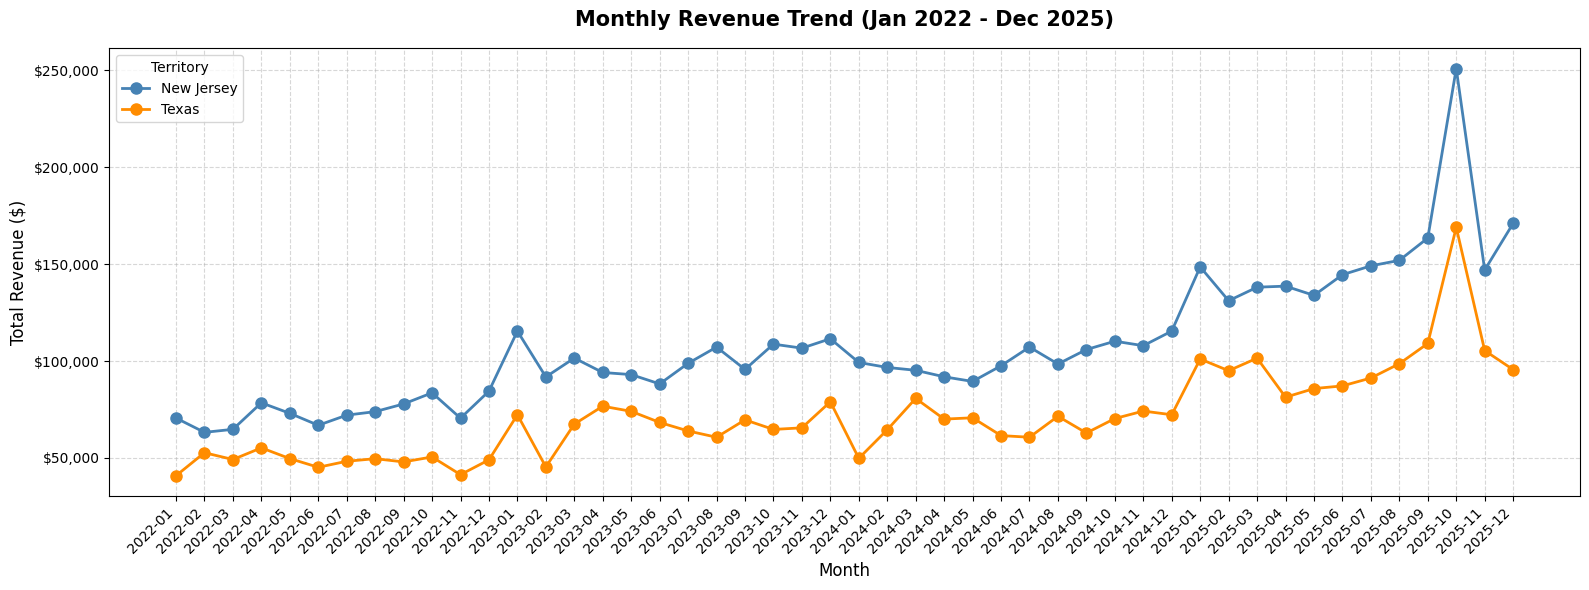

In [44]:
# Create Canvas
# Creating 1 figure eith 1 axe, 16 inches wide and 6 inches tall to fit all months
fig, ax = plt.subplots(figsize=(16, 6))

# Customzing each line
# New Jersey Trend
ax.plot(revenue.index.astype(str), 
        revenue['New Jersey'], 
        label='New Jersey', 
        color='steelblue', 
        linewidth=2, 
        marker='o', 
        markersize=8)

# Texas Trend
ax.plot(revenue.index.astype(str), 
        revenue['Texas'], 
        label='Texas', 
        color='darkorange', 
        linewidth=2, 
        marker='o', 
        markersize=8)

# Labels and Title
ax.set_title('Monthly Revenue Trend (Jan 2022 - Dec 2025)', fontsize=15, fontweight='bold', pad=16)
# thickness of title, font size, and pad=14 space between title and chart
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Revenue ($)', fontsize=12)

# Formatting
# formats y-axis tick labels with $ sign and comma separator
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Rotatiting x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Adding legend box
plt.legend(title='Territory')

# Adding gridlines
plt.grid(True, linestyle='--', alpha=0.5)

# Displaying the chart with nothing cut off
plt.tight_layout()
plt.show()